In [50]:
# ======================================================
# STEP 1: IMPORT ALL REQUIRED LIBRARIES
# ======================================================

# Data Handling
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)
from sklearn.metrics import roc_curve

# Scaling (if needed later)
from sklearn.preprocessing import StandardScaler

# SMOTE (optional, if used later)
from imblearn.over_sampling import SMOTE

# Plots
import matplotlib.pyplot as plt
import seaborn as sns


# Timing
import time

# Ignore warnings (cleaner output)
import warnings
warnings.filterwarnings("ignore")

import joblib   # for saving models


In [51]:
# ======================================================
# LOAD THE DATASET
# ======================================================
df = pd.read_csv("TelcoChurn_Top25_XGB.csv")

print("Data loaded. Shape:", df.shape)
df.head()

Data loaded. Shape: (7032, 26)


,Contract_Payment_Month-to-month_Electronic check,InternetService_Fiber optic,Contract_Two year,OnlineSecurity_No internet service,Contract_One year,OnlineBackup_No internet service,InternetService_No,DeviceProtection_No internet service,StreamingMovies_Yes,tenure,...,TotalCharges,MultipleLines_Yes,MonthlyCharges,Contract_Payment_Month-to-month_Credit card (automatic),AvgChargesPerMonth,StreamingTV_Yes,OnlineBackup_Yes,MultipleLines_No phone service,SeniorCitizen,Churn
0,1,0,0,0,0,0,0,0,0,-1.280248,...,-0.994194,0,-1.161694,0,-1.157889,0,1,1,-0.440327,0
1,0,0,0,0,1,0,0,0,0,0.064303,...,-0.173740,0,-0.260878,0,-0.305658,0,0,0,-0.440327,0
2,0,0,0,0,0,0,0,0,0,-1.239504,...,-0.959649,0,-0.363923,0,-0.355305,0,1,0,-0.440327,1
3,0,0,0,0,1,0,0,0,0,0.512486,...,-0.195248,0,-0.747850,0,-0.791614,0,0,1,-0.440327,0
4,1,1,0,0,0,0,0,0,0,-1.239504,...,-0.940457,0,0.196178,0,0.365282,0,0,0,-0.440327,1


In [52]:
# ======================================================
# STEP 2: PREPARE FEATURES AND TARGET + TRAIN/TEST SPLIT
# ======================================================

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps same churn distribution in train & test
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5625, 25)
Test shape: (1407, 25)


In [53]:
# Global results list for storing model metrics
model_results = []

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR Params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
LR Training Time: 3.344 sec
Best Threshold (LR): 0.4299999999999998
Best F1 at Threshold: 0.6307692307692307

--- Logistic Regression Evaluation ---
Accuracy: 0.7953091684434968
Recall: 0.6577540106951871
Precision: 0.6059113300492611
F1 Score: 0.6307692307692307
ROC-AUC: 0.8371184080426152

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1033
           1       0.61      0.66      0.63       374

    accuracy                           0.80      1407
   macro avg       0.74      0.75      0.74      1407
weighted avg       0.80      0.80      0.80      1407



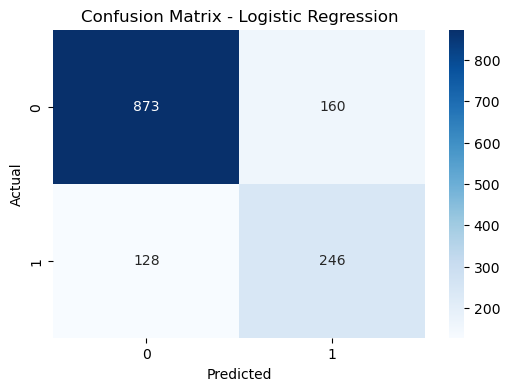

Saved model: LogisticRegression_BestModel.sav


In [54]:
# ======================================================
# STEP 3: LOGISTIC REGRESSION with GridSearchCV + Auto Threshold + Save Model
# ======================================================

# ----------------------------------------
# 3.1 Define parameter grid for LR
# ----------------------------------------
lr_param_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear"]  # supports both L1 and L2
}

# ----------------------------------------
# 3.2 GridSearchCV for LR
# ----------------------------------------
lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=500),
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train with timing
start_lr = time.time()
lr_grid.fit(X_train, y_train)
end_lr = time.time()

print("Best LR Params:", lr_grid.best_params_)
print("LR Training Time:", round(end_lr - start_lr, 3), "sec")

# Best estimator
lr_best = lr_grid.best_estimator_

# ----------------------------------------
# 3.3 Predict probabilities (for threshold tuning)
# ----------------------------------------
y_prob_lr = lr_best.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# ----------------------------------------
# 3.4 Auto threshold selection (max F1-score)
# ----------------------------------------
thresholds = np.arange(0.1, 0.91, 0.01)

best_f1 = 0
best_threshold = 0.5

for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold (LR):", best_threshold)
print("Best F1 at Threshold:", best_f1)

# ----------------------------------------
# 3.5 Final predictions using best threshold
# ----------------------------------------
y_pred_lr = (y_prob_lr >= best_threshold).astype(int)

# ----------------------------------------
# 3.6 Metrics
# ----------------------------------------
print("\n--- Logistic Regression Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# ----------------------------------------
# 3.7 Confusion Matrix Plot
# ----------------------------------------
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------------------
# 3.8 Save Model
# ----------------------------------------
joblib.dump(lr_best, "LogisticRegression_BestModel.sav")
print("Saved model: LogisticRegression_BestModel.sav")

# ----------------------------------------
# Save LR results
# ----------------------------------------
model_results.append({
    "model": "Logistic Regression",
    "roc_auc": roc_auc_score(y_test, y_prob_lr),
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "best_threshold": best_threshold,
    "train_time_sec": round(end_lr - start_lr, 4),
    "fpr": fpr_lr,
    "tpr": tpr_lr
})

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best RF Params: {'bootstrap': True, 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
RF Training Time: 3.686 sec
Best Threshold (RF): 0.3599999999999999
Best F1 at Threshold: 0.6338535414165666

--- Random Forest Evaluation ---
Accuracy: 0.783226723525231
Recall: 0.7058823529411765
Precision: 0.5751633986928104
F1 Score: 0.6338535414165666
ROC-AUC: 0.8390894595979728

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1033
           1       0.58      0.71      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.80      0.78      0.79      1407



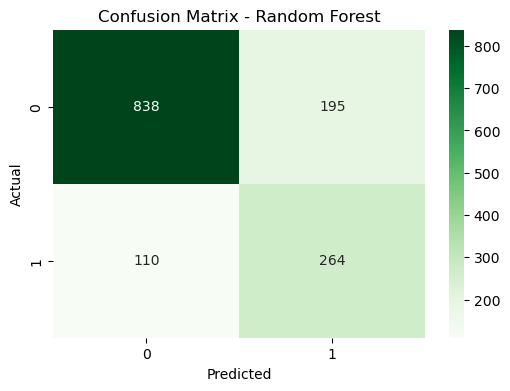

Saved model: RandomForest_BestModel.sav


In [55]:
# ======================================================
# STEP 4: RANDOM FOREST with GridSearchCV + Auto Threshold + Save Model
# ======================================================

from sklearn.ensemble import RandomForestClassifier

# ----------------------------------------
# 4.1 Define RF Parameter Grid
# ----------------------------------------
rf_param_grid = {
    "n_estimators": [300],
    "max_depth": [6, 10, None],
    "min_samples_split": [5],
    "min_samples_leaf": [2],
    "bootstrap": [True]
}

# ----------------------------------------
# 4.2 GridSearchCV for RF
# ----------------------------------------
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train with timing
start_rf = time.time()
rf_grid.fit(X_train, y_train)
end_rf = time.time()

print("Best RF Params:", rf_grid.best_params_)
print("RF Training Time:", round(end_rf - start_rf, 3), "sec")

# Best estimator
rf_best = rf_grid.best_estimator_

# ----------------------------------------
# 4.3 Predict probabilities (for threshold tuning)
# ----------------------------------------
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# ----------------------------------------
# 4.4 Auto threshold selection (max F1)
# ----------------------------------------
thresholds = np.arange(0.1, 0.91, 0.01)

best_f1_rf = 0
best_threshold_rf = 0.5

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1_rf:
        best_f1_rf = f1
        best_threshold_rf = t

print("Best Threshold (RF):", best_threshold_rf)
print("Best F1 at Threshold:", best_f1_rf)

# ----------------------------------------
# 4.5 Final predictions using best threshold
# ----------------------------------------
y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)


# ----------------------------------------
# 4.6 Metrics
# ----------------------------------------
print("\n--- Random Forest Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# ----------------------------------------
# 4.7 Confusion Matrix Plot
# ----------------------------------------
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------------------
# 4.8 Save Model
# ----------------------------------------
joblib.dump(rf_best, "RandomForest_BestModel.sav")
print("Saved model: RandomForest_BestModel.sav")

# ----------------------------------------
# 4.9 Save RF results
# ----------------------------------------
model_results.append({
    "model": "Random Forest",
    "roc_auc": roc_auc_score(y_test, y_prob_rf),
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "best_threshold": best_threshold_rf,
    "train_time_sec": round(end_rf - start_rf, 4),
    "fpr": fpr_rf,
    "tpr": tpr_rf
})


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
XGBoost Training Time: 14.435 sec
Best Threshold (XGBoost): 0.3199999999999999
Best F1 at Threshold: 0.6365638766519823

--- XGBoost Evaluation ---
Accuracy: 0.7654584221748401
Recall: 0.7727272727272727
Precision: 0.5411985018726592
F1 Score: 0.6365638766519823
ROC-AUC: 0.8418434961769623

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1033
           1       0.54      0.77      0.64       374

    accuracy                           0.77      1407
   macro avg       0.72      0.77      0.73      1407
weighted avg       0.81      0.77      0.78      1407



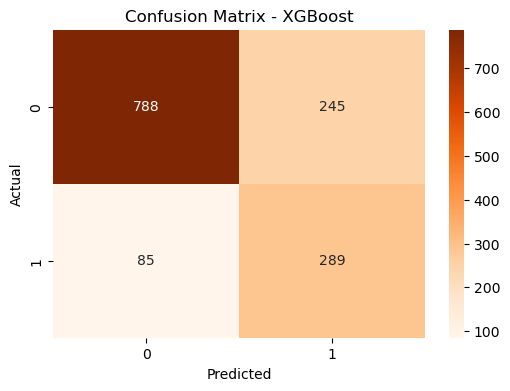

Saved model: XGBoost_BestModel.sav


In [56]:

# ----------------------------------------
# 5.1 XGBoost parameter grid
# ----------------------------------------
xg_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xg_model = XGBClassifier(
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# ----------------------------------------
# 5.2 GridSearchCV for XGBoost
# ----------------------------------------
xg_grid = GridSearchCV(
    estimator=xg_model,
    param_grid=xg_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

start_xg = time.time()
xg_grid.fit(X_train, y_train)
end_xg = time.time()

print("Best XGBoost Params:", xg_grid.best_params_)
print("XGBoost Training Time:", round(end_xg - start_xg, 3), "sec")

# Best model
xg_best = xg_grid.best_estimator_

# ----------------------------------------
# 5.3 Predict probabilities for threshold tuning
# ----------------------------------------
y_prob_xg = xg_best.predict_proba(X_test)[:, 1]

fpr_xg, tpr_xg, _ = roc_curve(y_test, y_prob_xg)
# ----------------------------------------
# 5.4 Automatic threshold selection (max F1)
# ----------------------------------------
thresholds = np.arange(0.1, 0.91, 0.01)

best_f1_xg = 0
best_threshold_xg = 0.5

for t in thresholds:
    y_pred_t = (y_prob_xg >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1_xg:
        best_f1_xg = f1
        best_threshold_xg = t

print("Best Threshold (XGBoost):", best_threshold_xg)
print("Best F1 at Threshold:", best_f1_xg)

# ----------------------------------------
# 5.5 Final predictions using best threshold
# ----------------------------------------
y_pred_xg = (y_prob_xg >= best_threshold_xg).astype(int)

# ----------------------------------------
# 5.6 Evaluation metrics
# ----------------------------------------
print("\n--- XGBoost Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("Recall:", recall_score(y_test, y_pred_xg))
print("Precision:", precision_score(y_test, y_pred_xg))
print("F1 Score:", f1_score(y_test, y_pred_xg))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg))

# ----------------------------------------
# 5.7 Confusion Matrix Plot
# ----------------------------------------
cm = confusion_matrix(y_test, y_pred_xg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------------------
# 5.8 Save Model
# ----------------------------------------
joblib.dump(xg_best, "XGBoost_BestModel.sav")
print("Saved model: XGBoost_BestModel.sav")

# ----------------------------------------
# 5.9 Save XGBoost results
# ----------------------------------------
model_results.append({
    "model": "XGBoost",
    "roc_auc": roc_auc_score(y_test, y_prob_xg),
    "accuracy": accuracy_score(y_test, y_pred_xg),
    "recall": recall_score(y_test, y_pred_xg),
    "precision": precision_score(y_test, y_pred_xg),
    "f1": f1_score(y_test, y_pred_xg),
    "best_threshold": best_threshold_xg,
    "train_time_sec": round(end_xg - start_xg, 4),
    "fpr": fpr_xg,
    "tpr": tpr_xg
})

Stacking Training Time: 3.635 sec
Best Threshold (Stacking): 0.3699999999999999
Best F1 (Stacking): 0.6330390920554855

--- STACKING ENSEMBLE Evaluation ---
Accuracy: 0.7931769722814499
Recall: 0.6711229946524064
Precision: 0.5990453460620525
F1 Score: 0.6330390920554855
ROC-AUC: 0.8423314058528454

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1033
           1       0.60      0.67      0.63       374

    accuracy                           0.79      1407
   macro avg       0.74      0.75      0.74      1407
weighted avg       0.80      0.79      0.80      1407



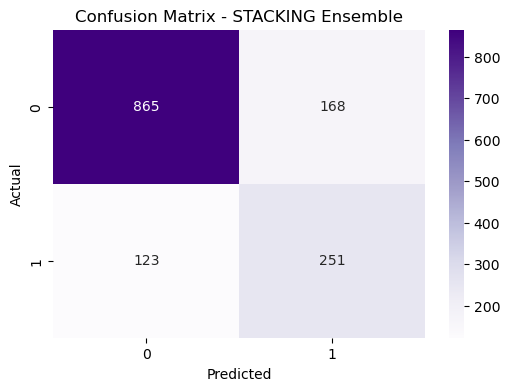

Saved model: StackingEnsemble_BestModel.sav


In [57]:
# ======================================================
# STEP 7: STACKING ENSEMBLE + Auto Threshold + Save Model
# ======================================================

# Base models (using best models from GridSearchCV, normal data)
estimators = [
    ("lr", lr_best),
    ("rf", rf_best),
    ("xg", xg_best)
]

# Meta-model
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=500),
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False
)

# ------------------------------------------------------
# Train stacking model
# ------------------------------------------------------
start_stack = time.time()
stack_model.fit(X_train, y_train)
end_stack = time.time()

print("Stacking Training Time:", round(end_stack - start_stack, 3), "sec")

# ------------------------------------------------------
# Predict probabilities for threshold tuning
# ------------------------------------------------------
y_prob_stack = stack_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_prob_stack)

# ------------------------------------------------------
# Auto threshold selection (MAX F1)
# ------------------------------------------------------
thresholds = np.arange(0.1, 0.91, 0.01)

best_f1_stack = 0
best_threshold_stack = 0.5

for t in thresholds:
    y_pred_t = (y_prob_stack >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1_stack:
        best_f1_stack = f1
        best_threshold_stack = t

print("Best Threshold (Stacking):", best_threshold_stack)
print("Best F1 (Stacking):", best_f1_stack)

# ------------------------------------------------------
# MAKE FINAL PREDICTIONS USING BEST THRESHOLD
# ------------------------------------------------------
y_pred_stack = (y_prob_stack >= best_threshold_stack).astype(int)

# ------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------
print("\n--- STACKING ENSEMBLE Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("F1 Score:", f1_score(y_test, y_pred_stack))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stack))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

# ------------------------------------------------------
# Confusion Matrix Plot
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - STACKING Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------------------------------------------
# Save stacking model
# ------------------------------------------------------
joblib.dump(stack_model, "StackingEnsemble_BestModel.sav")
print("Saved model: StackingEnsemble_BestModel.sav")

# ------------------------------------------------------
# Save stacking results
# ------------------------------------------------------
model_results.append({
    "model": "Stacking Ensemble",
    "roc_auc": roc_auc_score(y_test, y_prob_stack),
    "accuracy": accuracy_score(y_test, y_pred_stack),
    "recall": recall_score(y_test, y_pred_stack),
    "precision": precision_score(y_test, y_pred_stack),
    "f1": f1_score(y_test, y_pred_stack),
    "best_threshold": best_threshold_stack,
    "train_time_sec": round(end_stack - start_stack, 4),
    "fpr": fpr_stack,
    "tpr": tpr_stack
})


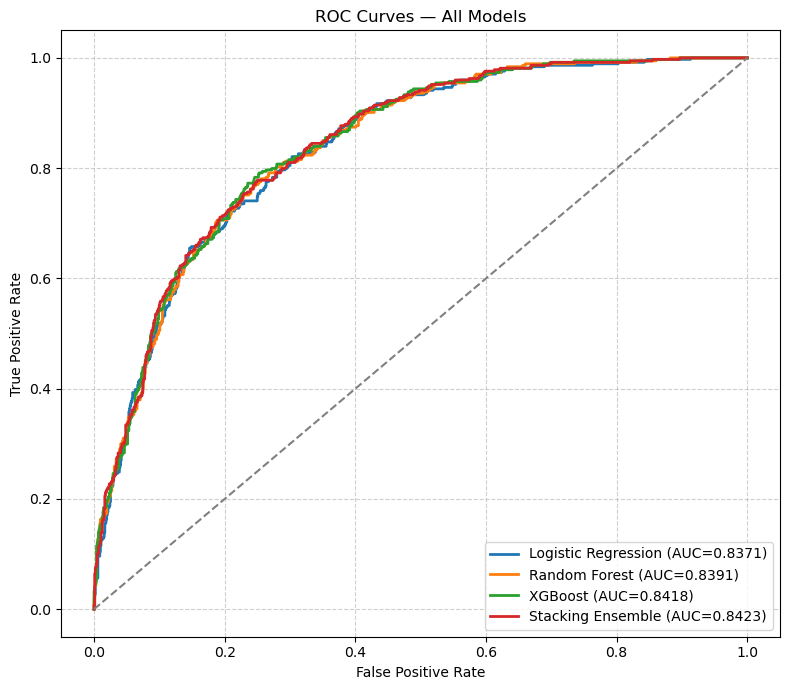

In [58]:
plt.figure(figsize=(8,7))

for res in model_results:
    if res["roc_auc"] is not None:
        plt.plot(
            res["fpr"], res["tpr"], lw=2,
            label=f"{res['model']} (AUC={res['roc_auc']:.4f})"
        )

plt.plot([0,1],[0,1],"--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [59]:
results_df = pd.DataFrame(model_results)

# Keep only the main metrics
results_df = results_df[
    ["model", "roc_auc", "accuracy", "recall", "precision", "f1",
     "best_threshold", "train_time_sec"]
]

# ======================================================
# SORT BY RECALL FIRST, THEN ROC-AUC
# ======================================================
results_sorted = results_df.sort_values(
    by=["recall", "roc_auc"], 
    ascending=[False, False]
).reset_index(drop=True)

print("=== SORTED MODEL PERFORMANCE TABLE ===")
display(results_sorted)

=== SORTED MODEL PERFORMANCE TABLE ===


,model,roc_auc,accuracy,recall,precision,f1,best_threshold,train_time_sec
0,XGBoost,0.841843,0.765458,0.772727,0.541199,0.636564,0.32,14.4351
1,Random Forest,0.839089,0.783227,0.705882,0.575163,0.633854,0.36,3.6859
2,Stacking Ensemble,0.842331,0.793177,0.671123,0.599045,0.633039,0.37,3.6348
3,Logistic Regression,0.837118,0.795309,0.657754,0.605911,0.630769,0.43,3.3442


In [60]:
# Keep only numeric metrics for heatmap
heatmap_df = results_df.set_index("model")[
    ["roc_auc", "accuracy", "recall", "precision", "f1"]
]

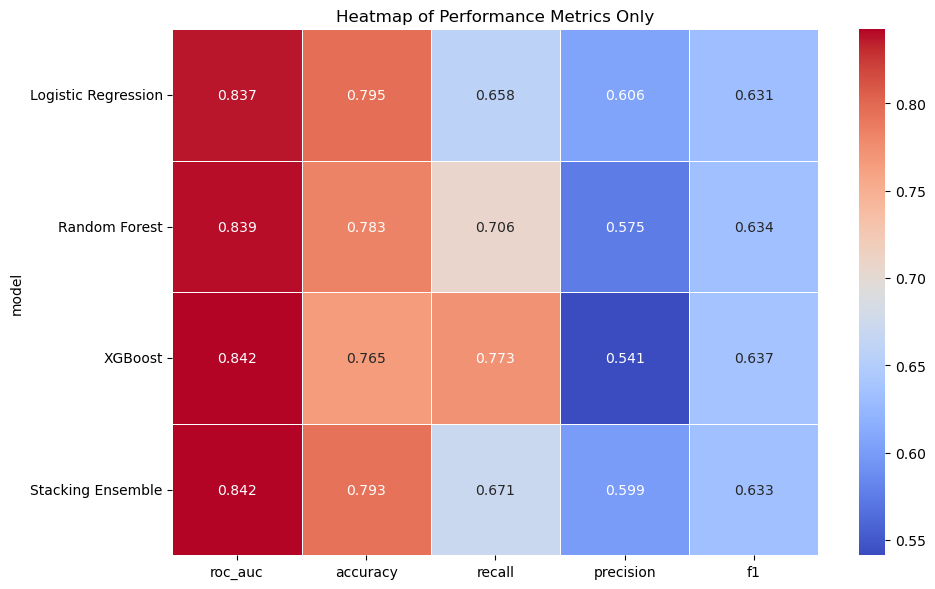

In [61]:
heatmap_df_perf = heatmap_df[["roc_auc", "accuracy", "recall", "precision", "f1",]]

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df_perf,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap of Performance Metrics Only")
plt.tight_layout()
plt.show()


In [96]:
# ======================================================
# SMOTE-Tomek: Apply ONLY on Training Data (same variables)
# ======================================================

from imblearn.combine import SMOTETomek
from collections import Counter

print("Original y_train class distribution:", Counter(y_train))

smote_tomek = SMOTETomek(random_state=42)
X_train_sm, y_train_sm = smote_tomek.fit_resample(X_train, y_train)

print("After SMOTE-Tomek y_train class distribution:", Counter(y_train_sm))
print("Original X_train shape:", X_train.shape)
print("SMOTE-Tomek X_train_sm shape:", X_train_sm.shape)

# keep your results container the same
model_results_smote = []


Original y_train class distribution: Counter({0: 4130, 1: 1495})
After SMOTE-Tomek y_train class distribution: Counter({0: 3888, 1: 3888})
Original X_train shape: (5625, 25)
SMOTE-Tomek X_train_sm shape: (7776, 25)


Class distribution before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64


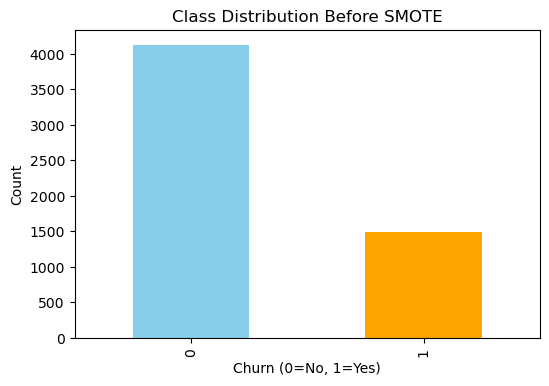

In [98]:
# Check class distribution before SMOTE
print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts())

plt.figure(figsize=(6,4))
pd.Series(y_train).value_counts().plot(kind='bar', color=['skyblue','orange'])
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

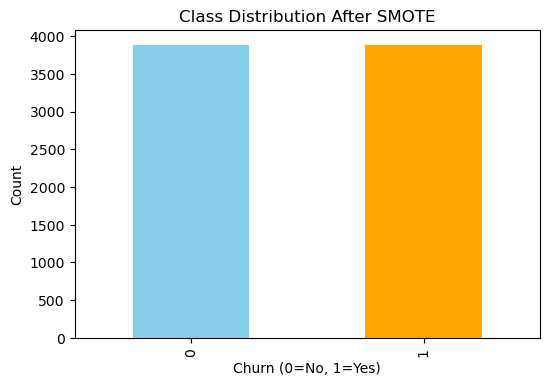

In [100]:
plt.figure(figsize=(6,4))
pd.Series(y_train_sm).value_counts().plot(kind='bar', color=['skyblue','orange'])
plt.title("Class Distribution After SMOTE")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR Params (SMOTE): {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
LR Training Time (SMOTE): 5.317 sec
Best Threshold (LR SMOTE): 0.6399999999999997
Best F1 at Threshold (SMOTE): 0.6208588957055214

--- Logistic Regression (SMOTE) Evaluation ---
Accuracy: 0.7803837953091685
Recall: 0.6764705882352942
Precision: 0.5736961451247166
F1 Score: 0.6208588957055214
ROC-AUC: 0.8256984744086846

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1033
           1       0.57      0.68      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.79      0.78      0.79      1407



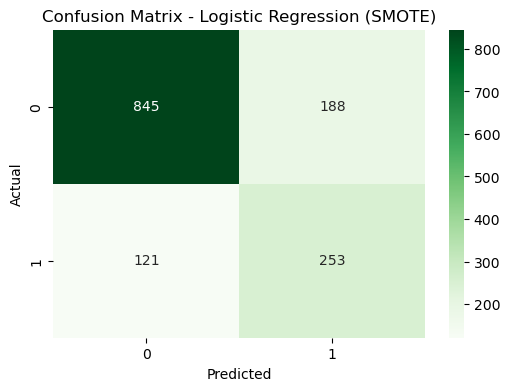

Saved model: LogisticRegression_SMOTE.sav


In [102]:
# ======================================================
# SMOTE STEP 2: LOGISTIC REGRESSION with GridSearchCV + Auto Threshold + Save Model
# ======================================================

# ----------------------------------------
# 2.1 Define parameter grid for LR
# ----------------------------------------
lr_param_grid = {
    "penalty": ["l1", "l2"],
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear"]  # supports both L1 and L2
}

# ----------------------------------------
# 2.2 GridSearchCV for LR (SMOTE data)
# ----------------------------------------
lr_grid_sm = GridSearchCV(
    estimator=LogisticRegression(max_iter=500),
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train with timing
start_lr_sm = time.time()
lr_grid_sm.fit(X_train_sm, y_train_sm)
end_lr_sm = time.time()

print("Best LR Params (SMOTE):", lr_grid_sm.best_params_)
print("LR Training Time (SMOTE):", round(end_lr_sm - start_lr_sm, 3), "sec")

# Best estimator
lr_best_sm = lr_grid_sm.best_estimator_

# ----------------------------------------
# 2.3 Predict probabilities on **original test set**
# ----------------------------------------
y_prob_lr_sm = lr_best_sm.predict_proba(X_test)[:, 1]

# ROC curve points
fpr_lr_sm, tpr_lr_sm, _ = roc_curve(y_test, y_prob_lr_sm)

# ----------------------------------------
# 2.4 Auto threshold selection (max F1-score)
# ----------------------------------------
thresholds = np.arange(0.1, 0.91, 0.01)

best_f1_sm = 0
best_threshold_lr_sm = 0.5

for t in thresholds:
    y_pred_t = (y_prob_lr_sm >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1_sm:
        best_f1_sm = f1
        best_threshold_lr_sm = t

print("Best Threshold (LR SMOTE):", best_threshold_lr_sm)
print("Best F1 at Threshold (SMOTE):", best_f1_sm)

# ----------------------------------------
# 2.5 Final predictions using best threshold
# ----------------------------------------
y_pred_lr_sm = (y_prob_lr_sm >= best_threshold_lr_sm).astype(int)

# ----------------------------------------
# 2.6 Evaluation Metrics
# ----------------------------------------
print("\n--- Logistic Regression (SMOTE) Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_sm))
print("Recall:", recall_score(y_test, y_pred_lr_sm))
print("Precision:", precision_score(y_test, y_pred_lr_sm))
print("F1 Score:", f1_score(y_test, y_pred_lr_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_sm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_sm))

# ----------------------------------------
# 2.7 Confusion Matrix Plot
# ----------------------------------------
cm = confusion_matrix(y_test, y_pred_lr_sm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Logistic Regression (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------------------
# 2.8 Save Model
# ----------------------------------------
joblib.dump(lr_best_sm, "LogisticRegression_SMOTE.sav")
print("Saved model: LogisticRegression_SMOTE.sav")

# ----------------------------------------
# 2.9 Save SMOTE LR results
# ----------------------------------------
model_results_smote.append({
    "model": "Logistic Regression (SMOTE)",
    "roc_auc": roc_auc_score(y_test, y_prob_lr_sm),
    "accuracy": accuracy_score(y_test, y_pred_lr_sm),
    "recall": recall_score(y_test, y_pred_lr_sm),
    "precision": precision_score(y_test, y_pred_lr_sm),
    "f1": f1_score(y_test, y_pred_lr_sm),
    "best_threshold": best_threshold_lr_sm,
    "train_time_sec": round(end_lr_sm - start_lr_sm, 4),
    "fpr": fpr_lr_sm,
    "tpr": tpr_lr_sm
})


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best RF Params (SMOTE): {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
RF Training Time (SMOTE): 10.727 sec
Best Threshold (RF SMOTE): 0.48999999999999977
Best F1 at Threshold (SMOTE): 0.6234906695938529

--- Random Forest (SMOTE) Evaluation ---
Accuracy: 0.7562189054726368
Recall: 0.7593582887700535
Precision: 0.5288640595903166
F1 Score: 0.6234906695938529
ROC-AUC: 0.8316142174550011

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407



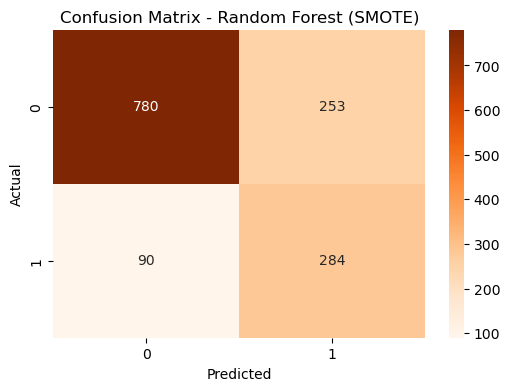

Saved model: RandomForest_SMOTE.sav


In [104]:
# ======================================================
# SMOTE STEP 3: RANDOM FOREST with GridSearchCV + Auto Threshold + Save Model
# ======================================================

# ----------------------------------------
# 3.1 Define parameter grid for Random Forest
# ----------------------------------------
rf_param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [6, 8, 10],
    "min_samples_split": [5],
    "min_samples_leaf": [2]
}

# ----------------------------------------
# 3.2 GridSearchCV for RF (SMOTE data)
# ----------------------------------------
rf_grid_sm = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train with timing
start_rf_sm = time.time()
rf_grid_sm.fit(X_train_sm, y_train_sm)
end_rf_sm = time.time()

print("Best RF Params (SMOTE):", rf_grid_sm.best_params_)
print("RF Training Time (SMOTE):", round(end_rf_sm - start_rf_sm, 3), "sec")

# Best estimator
rf_best_sm = rf_grid_sm.best_estimator_

# ----------------------------------------
# 3.3 Predict probabilities on original test set
# ----------------------------------------
y_prob_rf_sm = rf_best_sm.predict_proba(X_test)[:, 1]

# ROC curve
fpr_rf_sm, tpr_rf_sm, _ = roc_curve(y_test, y_prob_rf_sm)

# ----------------------------------------
# 3.4 Auto threshold selection (max F1-score)
# ----------------------------------------
thresholds = np.arange(0.1, 0.91, 0.01)

best_f1_rf_sm = 0
best_threshold_rf_sm = 0.5

for t in thresholds:
    y_pred_t = (y_prob_rf_sm >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1_rf_sm:
        best_f1_rf_sm = f1
        best_threshold_rf_sm = t

print("Best Threshold (RF SMOTE):", best_threshold_rf_sm)
print("Best F1 at Threshold (SMOTE):", best_f1_rf_sm)

# ----------------------------------------
# 3.5 Final predictions using best threshold
# ----------------------------------------
y_pred_rf_sm = (y_prob_rf_sm >= best_threshold_rf_sm).astype(int)

# ----------------------------------------
# 3.6 Evaluation Metrics
# ----------------------------------------
print("\n--- Random Forest (SMOTE) Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_sm))
print("Recall:", recall_score(y_test, y_pred_rf_sm))
print("Precision:", precision_score(y_test, y_pred_rf_sm))
print("F1 Score:", f1_score(y_test, y_pred_rf_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_sm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_sm))

# ----------------------------------------
# 3.7 Confusion Matrix Plot
# ----------------------------------------
cm = confusion_matrix(y_test, y_pred_rf_sm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------------------
# 3.8 Save Model
# ----------------------------------------
joblib.dump(rf_best_sm, "RandomForest_SMOTE.sav")
print("Saved model: RandomForest_SMOTE.sav")

# ----------------------------------------
# 3.9 Save RF SMOTE results
# ----------------------------------------
model_results_smote.append({
    "model": "Random Forest (SMOTE)",
    "roc_auc": roc_auc_score(y_test, y_prob_rf_sm),
    "accuracy": accuracy_score(y_test, y_pred_rf_sm),
    "recall": recall_score(y_test, y_pred_rf_sm),
    "precision": precision_score(y_test, y_pred_rf_sm),
    "f1": f1_score(y_test, y_pred_rf_sm),
    "best_threshold": best_threshold_rf_sm,
    "train_time_sec": round(end_rf_sm - start_rf_sm, 4),
    "fpr": fpr_rf_sm,
    "tpr": tpr_rf_sm
})


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost Params (SMOTE): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 1.0}
XGBoost Training Time (SMOTE): 18.183 sec
Best Threshold (XGBoost SMOTE): 0.32999999999999985
Best F1 at Threshold (SMOTE): 0.6114101184068891

--- XGBoost (SMOTE) Evaluation ---
Accuracy: 0.7434257285003554
Recall: 0.7593582887700535
Precision: 0.5117117117117117
F1 Score: 0.6114101184068891
ROC-AUC: 0.8125507969622769

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407



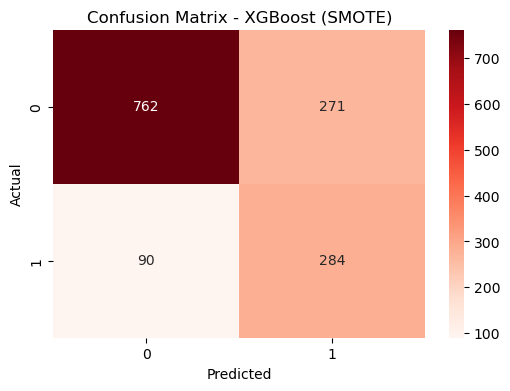

Saved model: XGBoost_SMOTE.sav


In [106]:
# ======================================================
# SMOTE STEP 4: XGBOOST with GridSearchCV + Auto Threshold + Save Model
# ======================================================

# ----------------------------------------
# 4.1 Define parameter grid for XGBoost
# ----------------------------------------
xg_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Base XGB model
xg_model_sm = XGBClassifier(
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# ----------------------------------------
# 4.2 GridSearchCV for XGBoost (SMOTE data)
# ----------------------------------------
xg_grid_sm = GridSearchCV(
    estimator=xg_model_sm,
    param_grid=xg_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train with timing
start_xg_sm = time.time()
xg_grid_sm.fit(X_train_sm, y_train_sm)
end_xg_sm = time.time()

print("Best XGBoost Params (SMOTE):", xg_grid_sm.best_params_)
print("XGBoost Training Time (SMOTE):", round(end_xg_sm - start_xg_sm, 3), "sec")

# Best estimator
xg_best_sm = xg_grid_sm.best_estimator_

# ----------------------------------------
# 4.3 Predict probabilities on original test set
# ----------------------------------------
y_prob_xg_sm = xg_best_sm.predict_proba(X_test)[:, 1]

# ROC curve
fpr_xg_sm, tpr_xg_sm, _ = roc_curve(y_test, y_prob_xg_sm)

# ----------------------------------------
# 4.4 Auto threshold selection (max F1-score)
# ----------------------------------------
thresholds = np.arange(0.1, 0.91, 0.01)

best_f1_xg_sm = 0
best_threshold_xg_sm = 0.5

for t in thresholds:
    y_pred_t = (y_prob_xg_sm >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1_xg_sm:
        best_f1_xg_sm = f1
        best_threshold_xg_sm = t

print("Best Threshold (XGBoost SMOTE):", best_threshold_xg_sm)
print("Best F1 at Threshold (SMOTE):", best_f1_xg_sm)

# ----------------------------------------
# 4.5 Final predictions using best threshold
# ----------------------------------------
y_pred_xg_sm = (y_prob_xg_sm >= best_threshold_xg_sm).astype(int)

# ----------------------------------------
# 4.6 Evaluation Metrics
# ----------------------------------------
print("\n--- XGBoost (SMOTE) Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xg_sm))
print("Recall:", recall_score(y_test, y_pred_xg_sm))
print("Precision:", precision_score(y_test, y_pred_xg_sm))
print("F1 Score:", f1_score(y_test, y_pred_xg_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xg_sm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xg_sm))

# ----------------------------------------
# 4.7 Confusion Matrix Plot
# ----------------------------------------
cm = confusion_matrix(y_test, y_pred_xg_sm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - XGBoost (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------------------
# 4.8 Save Model
# ----------------------------------------
joblib.dump(xg_best_sm, "XGBoost_SMOTE.sav")
print("Saved model: XGBoost_SMOTE.sav")

# ----------------------------------------
# 4.9 Save XGBoost SMOTE results
# ----------------------------------------
model_results_smote.append({
    "model": "XGBoost (SMOTE)",
    "roc_auc": roc_auc_score(y_test, y_prob_xg_sm),
    "accuracy": accuracy_score(y_test, y_pred_xg_sm),
    "recall": recall_score(y_test, y_pred_xg_sm),
    "precision": precision_score(y_test, y_pred_xg_sm),
    "f1": f1_score(y_test, y_pred_xg_sm),
    "best_threshold": best_threshold_xg_sm,
    "train_time_sec": round(end_xg_sm - start_xg_sm, 4),
    "fpr": fpr_xg_sm,
    "tpr": tpr_xg_sm
})


Training Time (BEST Stacking SMOTE): 3.329 seconds
Optimal Threshold (BEST Stacking SMOTE): 0.2899999999999999
Best F1 Score (SMOTE): 0.614406779661017

===== BEST STACKING SMOTE MODEL PERFORMANCE =====
Accuracy: 0.7412935323383084
Recall: 0.7754010695187166
Precision: 0.5087719298245614
F1 Score: 0.614406779661017
ROC-AUC: 0.8249789047010161

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



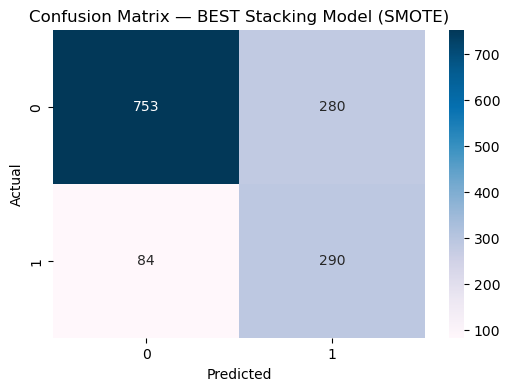

Saved best model as: BEST_Stacking_SMOTE.sav


In [108]:
estimators_best_sm = [
    ("lr", lr_best_sm),     # best Logistic Regression (SMOTE)
    ("rf", rf_best_sm),     # best Random Forest (SMOTE)
    ("xg", xg_best_sm)      # best XGBoost (SMOTE)
]

# Meta-learner
meta_model_sm = LogisticRegression(max_iter=500)

stack_best_sm = StackingClassifier(
    estimators=estimators_best_sm,
    final_estimator=meta_model_sm,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1
)


# ------------------------------------------------------
# 2. Train Stacking Ensemble on SMOTE data
# ------------------------------------------------------

start_stack_best = time.time()
stack_best_sm.fit(X_train_sm, y_train_sm)
end_stack_best = time.time()

print("Training Time (BEST Stacking SMOTE):", round(end_stack_best - start_stack_best, 3), "seconds")


# ------------------------------------------------------
# 3. Predict probabilities on original test set
# ------------------------------------------------------

y_prob_stack_best = stack_best_sm.predict_proba(X_test)[:, 1]

# ROC curve
fpr_stack_best, tpr_stack_best, _ = roc_curve(y_test, y_prob_stack_best)


# ------------------------------------------------------
# 4. Auto threshold optimization (MAX F1)
# ------------------------------------------------------

thresholds = np.arange(0.1, 0.91, 0.01)

best_f1_stack_best = 0
best_threshold_stack_best = 0.5

for t in thresholds:
    y_pred_t = (y_prob_stack_best >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    if f1 > best_f1_stack_best:
        best_f1_stack_best = f1
        best_threshold_stack_best = t

print("Optimal Threshold (BEST Stacking SMOTE):", best_threshold_stack_best)
print("Best F1 Score (SMOTE):", best_f1_stack_best)


# ------------------------------------------------------
# 5. Final predictions using best threshold
# ------------------------------------------------------

y_pred_stack_best = (y_prob_stack_best >= best_threshold_stack_best).astype(int)


# ------------------------------------------------------
# 6. Evaluation Metrics
# ------------------------------------------------------

print("\n===== BEST STACKING SMOTE MODEL PERFORMANCE =====")
print("Accuracy:", accuracy_score(y_test, y_pred_stack_best))
print("Recall:", recall_score(y_test, y_pred_stack_best))
print("Precision:", precision_score(y_test, y_pred_stack_best))
print("F1 Score:", f1_score(y_test, y_pred_stack_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stack_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack_best))


# ------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------

cm = confusion_matrix(y_test, y_pred_stack_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBu")
plt.title("Confusion Matrix — BEST Stacking Model (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ------------------------------------------------------
# 8. Save BEST Stacking Model
# ------------------------------------------------------

joblib.dump(stack_best_sm, "BEST_Stacking_SMOTE.sav")
print("Saved best model as: BEST_Stacking_SMOTE.sav")


# ------------------------------------------------------
# 9. Store results (optional)
# ------------------------------------------------------

model_results_smote.append({
    "model": "BEST Stacking (SMOTE)",
    "roc_auc": roc_auc_score(y_test, y_prob_stack_best),
    "accuracy": accuracy_score(y_test, y_pred_stack_best),
    "recall": recall_score(y_test, y_pred_stack_best),
    "precision": precision_score(y_test, y_pred_stack_best),
    "f1": f1_score(y_test, y_pred_stack_best),
    "best_threshold": best_threshold_stack_best,
    "train_time_sec": round(end_stack_best - start_stack_best, 4),
    "fpr": fpr_stack_best,
    "tpr": tpr_stack_best
})

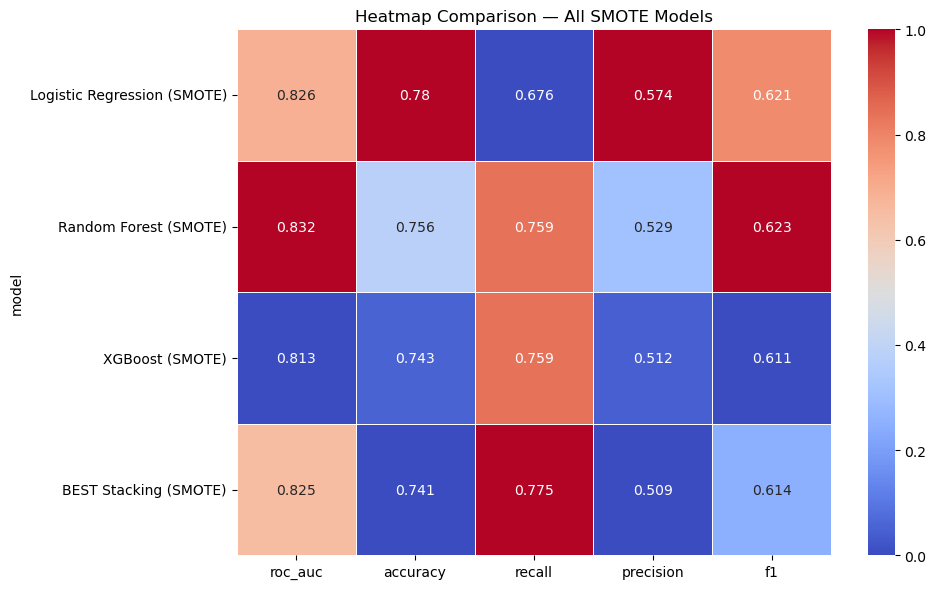

In [110]:
# ======================================================
# HEATMAP FOR ALL SMOTE MODELS
# ======================================================

results_smote_df = pd.DataFrame(model_results_smote)

# Select relevant metrics
heatmap_smote = results_smote_df.set_index("model")[
    ["roc_auc", "accuracy", "recall", "precision", "f1"]
]

# Normalize for better contrast
heatmap_smote_norm = (heatmap_smote - heatmap_smote.min()) / (heatmap_smote.max() - heatmap_smote.min())

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_smote_norm,
    annot=heatmap_smote.round(3),
    fmt="",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Heatmap Comparison — All SMOTE Models")
plt.tight_layout()
plt.show()


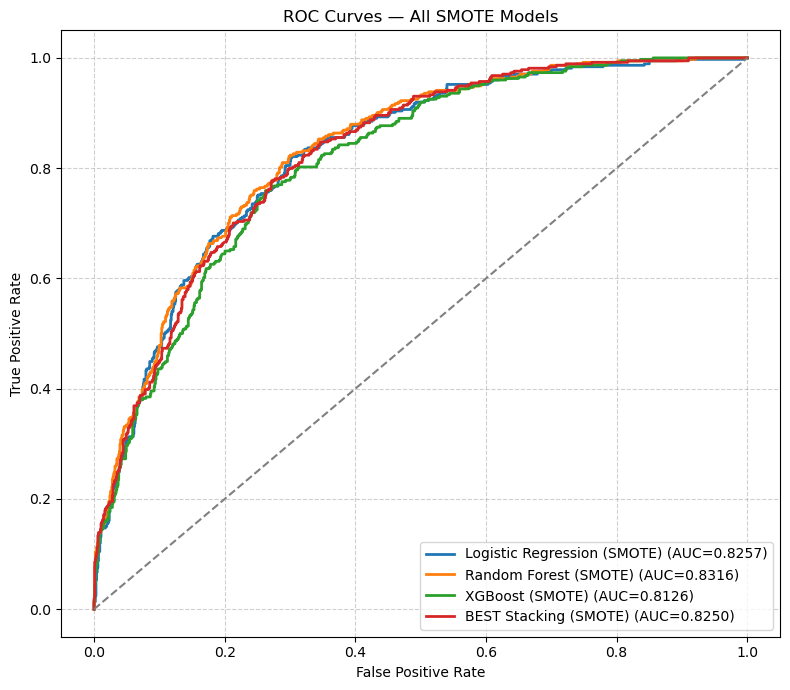

In [112]:
# ======================================================
# ROC CURVES FOR ALL SMOTE MODELS (ONE PLOT)
# ======================================================

plt.figure(figsize=(8,7))

for res in model_results_smote:
    model_name = res["model"]
    fpr = res["fpr"]
    tpr = res["tpr"]
    auc = res["roc_auc"]

    plt.plot(
        fpr, tpr, lw=2,
        label=f"{model_name} (AUC={auc:.4f})"
    )

# Random baseline
plt.plot([0,1], [0,1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All SMOTE Models")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [114]:
# Convert both lists to DataFrames
df_normal = pd.DataFrame(model_results)
df_smote = pd.DataFrame(model_results_smote)

# Add source labels
df_normal["type"] = "Normal"
df_smote["type"] = "SMOTE"

# Combine both
df_all = pd.concat([df_normal, df_smote], ignore_index=True)

# Select metrics for display
df_all = df_all[
    ["model", "type", "roc_auc", "accuracy", "recall", "precision", "f1", "best_threshold", "train_time_sec"]
]

# Ranking for churn prediction (Recall > ROC-AUC > F1)
df_ranked = df_all.sort_values(
    by=["recall", "roc_auc", "f1"], 
    ascending=[False, False, False]
).reset_index(drop=True)

# Display final ranked table
df_ranked

,model,type,roc_auc,accuracy,recall,precision,f1,best_threshold,train_time_sec
0,BEST Stacking (SMOTE),SMOTE,0.824979,0.741294,0.775401,0.508772,0.614407,0.29,3.3291
1,XGBoost,Normal,0.841843,0.765458,0.772727,0.541199,0.636564,0.32,14.4351
2,Random Forest (SMOTE),SMOTE,0.831614,0.756219,0.759358,0.528864,0.623491,0.49,10.7267
3,XGBoost (SMOTE),SMOTE,0.812551,0.743426,0.759358,0.511712,0.611410,0.33,18.1831
4,Random Forest,Normal,0.839089,0.783227,0.705882,0.575163,0.633854,0.36,3.6859
5,Logistic Regression (SMOTE),SMOTE,0.825698,0.780384,0.676471,0.573696,0.620859,0.64,5.3169
6,Stacking Ensemble,Normal,0.842331,0.793177,0.671123,0.599045,0.633039,0.37,3.6348
7,Logistic Regression,Normal,0.837118,0.795309,0.657754,0.605911,0.630769,0.43,3.3442
